# Tingen City Background — Prompt → Result

How the explorable city background is made, by hand in the **ChatGPT in-app image generator
(GPT-Image, the "image 2" tool)** — the screenshots below are the actual sessions. The prompts
are reproducible; `generate_tingen_image2.py` automates the same calls via the `gpt-image-1` API
if you want it scripted. Flow: **generate → relabel → split into background + buildings → compose
in Godot with colliders.**

## Step 1 — Generate the city (text → image)

Pure text-to-image. Style and the important features are all in the prose.

**Prompt:**
```
Top-down 2D game world map, late Victorian Britain working-class district, hand-painted
cartographic style. Dense brick row houses, small workshops, corner pubs, warehouses, tenements,
narrow alleys, irregular block layouts, varied roof heights and footprints. Dark slate roofs mixed
with weathered red brick roofs, numerous chimneys, soot-stained walls, patched roofs, aged stone
roads. Muted industrial color palette, overcast British daylight, low saturation, dusty browns,
faded reds, gray-blue slate, subtle atmospheric haze. Not wealthy, lived-in and practical. Strong
shape readability for a video game map. High visual variety between buildings while maintaining
coherent urban planning. Detailed but not photorealistic. Lord of the Mysteries / Tingen-inspired
Victorian city atmosphere.
```

**Result** — note the model auto-letters and garbles some names (e.g. GREENMARKET *SQUARK*),
which Step 2 fixes:

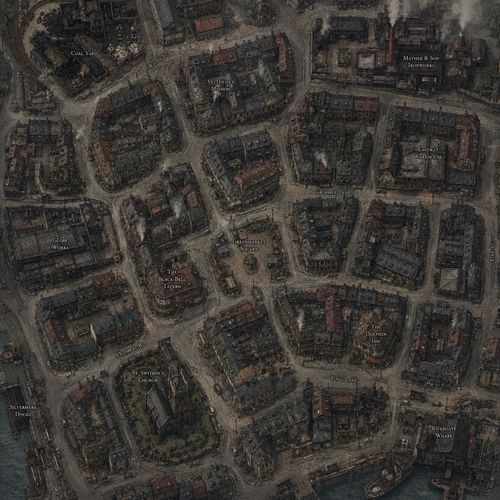

## Step 2 — Relabel to canon

Feed the Step-1 image back as the exact base and change **only** the text labels.

**Prompt:**
```
Use the attached image as the exact base. Keep everything visual identical -
same hand-painted style, same true straight-down 90 degree top-down angle, same grim
sooty Victorian dockside mood, same street layout, same buildings, same colours
and lighting. Do NOT redraw, move, add or remove any building, street, river or
shape. Change ONLY the text labels, keeping each label in its current position,
size and lettering style.

Rename these labels:
- the main market street through the centre  -> "Iron Cross Street"
- "GREENMARKET SQUARK" (the central square)  -> "Iron Cross Market"
- "The Black Bell Tavern"  -> "The Laughing Eel"
- "St. Swithin's Church"  -> "Saint Selena's Cathedral"
- the graveyard beside the church  -> "Raphael Cemetery"
- "St. Hilda's Mission"  -> "Selena's Almshouse"
- "Silvermere Docks"  -> "Tingen Docks"
- "Rivergate Wharf"  -> "River Wharves"

Leave these labels unchanged: Raven St, Grimmer Lane, Fogg Lane, Pixe St,
Oldmere Rd, Coal Yard, Mather & Son Ironworks, Eastway Warehouse, Globe Works.

Add labels to three existing unlabelled buildings (do NOT draw new buildings):
- "Blackthorn Security Co." on a side street labelled "Zouteland Street"
- "Tingen Police Station"
- "Mr. Franky's" (a lodging house)

Every label must be spelled EXACTLY as written above, in clean, legible lettering
matching the existing map labels. Make no other changes.
```

**The session:**

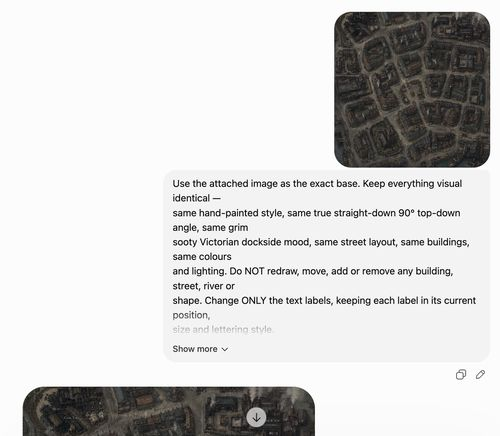

**Result** — same art, canon names:

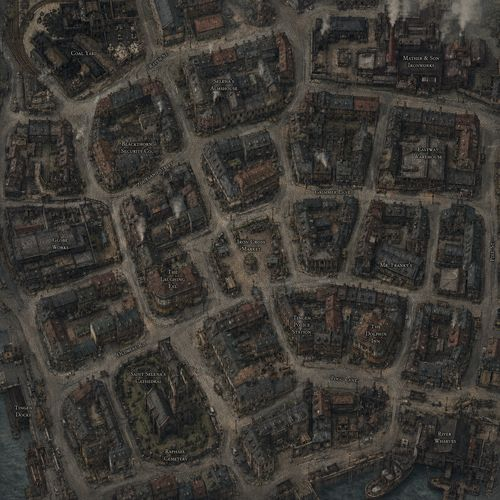

## Step 3a — Strip the buildings → background only

First of the two layers: feed the labeled map back and remove everything except the ground and the
river. The empty lots barely need detail (buildings cover them) — they just need to read as streets.

**Prompt:**
```
this was the map you generated, now generate the same map, with all buildings,
structures, labels removed. the only thing kept should be the ground and the river
```

**The session:**

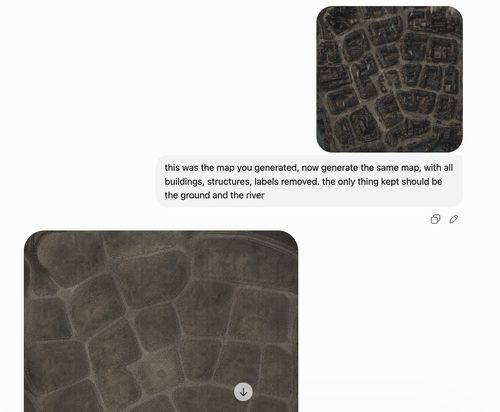

**Result** (`my_assets/map_bg.png`) — the bare walkable ground:

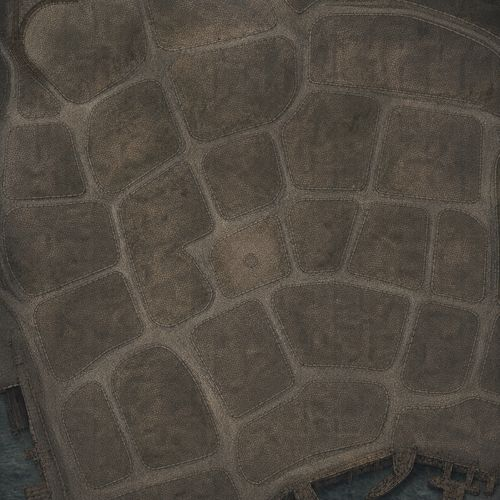

## Step 3b — Buildings only → transparent layer

The mirror edit, done **one building (compound) at a time** in two sub-steps. Example: St. Selena's
Cathedral = chapel + churchyard + fence.

**Sub-step 1 — detail the building full-screen** (so the cutout has enough resolution):
```
generate a more detailed, full screen image of the st.selena's chapel, true to the provided image
```

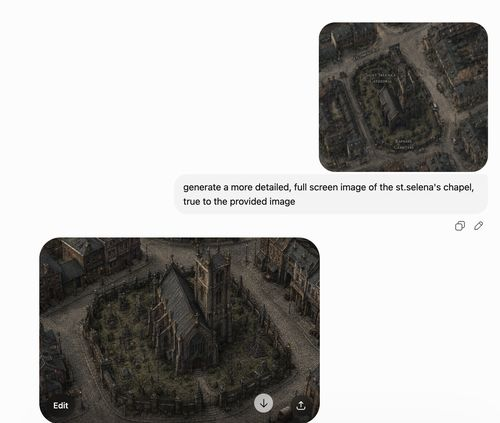

**Sub-step 2 — cut it out on transparency:**
```
remove everything outside of the fence, keep the background transparent.
only keep the chapel and teh yard and the fences,
```

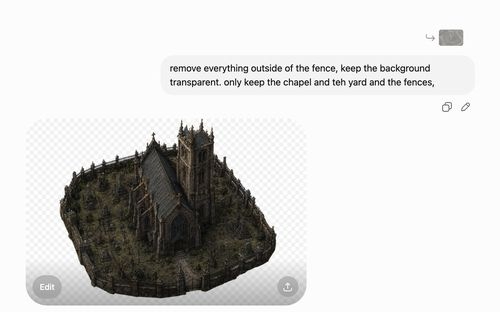

If a building returns on a white halo instead of clean alpha, `key_building.py` finishes the job
(KEY border-white → ERODE the fringe → BLEED nearest colour). The keyed asset in-repo
(`St_Selena_Chapel_v2.png`):

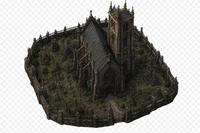

## Step 4 — Compose in Godot (background + buildings + colliders)

Assemble the two layers in the `.tscn` and make the buildings **solid** so the player/agents route
around them. The real composed scene is `tingen/scenes/CityBlocks.tscn`: one walkable `Ground` polygon
(the background) + a `Buildings` node of `StaticBody2D`s, each with a `Polygon2D` (visual) **and** a
`CollisionPolygon2D` (the footprint collider):

```gdscript
[node name="Ground" type="Polygon2D" parent="."]                          # background / walkable floor
polygon = PackedVector2Array(0, 0, 2400, 0, 2400, 1700, 0, 1700)

[node name="B_r0_c0" type="StaticBody2D" parent="Buildings"]               # one building
[node name="Polygon2D" type="Polygon2D" parent="Buildings/B_r0_c0"]        # building visual (from 3b)
polygon = PackedVector2Array(-76.8, -58.8, 76.8, -58.8, 76.8, 58.8, -76.8, 58.8)
[node name="CollisionPolygon2D" type="CollisionPolygon2D" parent="Buildings/B_r0_c0"]   # THE collider
polygon = PackedVector2Array(-76.8, -58.8, 76.8, -58.8, 76.8, 58.8, -76.8, 58.8)
```

- **Background:** `map_bg.png` as the ground (`texture_filter = Linear` for smooth upscale of painted art).
- **Buildings:** the keyed sprite(s) from 3b stamped at their footprint, each in a `StaticBody2D` +
  `CollisionPolygon2D` → solid obstacle.
- Hold the camera at gameplay zoom; the collider footprints are what the player and NPC agents route around.

**The composed scene in Godot** (`City.tscn` — `Solids` / `Ground` + `Chapel` + the `Player` with collision):

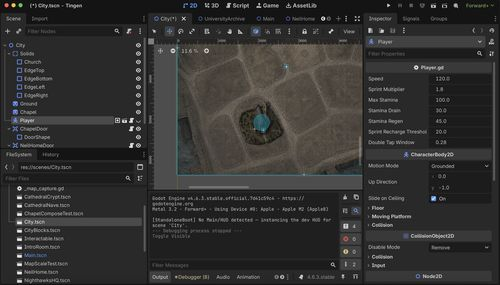

**TL;DR:** generate the top-down city → relabel to canon → split into a background-only layer (3a) and a
buildings-only layer (3b) → compose in Godot as `map_bg` ground + building sprites, each wrapped in a
`StaticBody2D` + `CollisionPolygon2D`. (Steps 1–2 done in the ChatGPT in-app image tool; the same calls
are scriptable via `generate_tingen_image2.py` / the `gpt-image-1` API.)